In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_fscore_support
from sklearn.calibration import calibration_curve
import xgboost as xgb

df = pd.read_csv("accepted_loans.csv")
df.head()

C:\Users\Ashvik\AppData\Local\Temp\ipykernel_19280\1495728364.py:12: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("accepted_loans.csv")


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Define the mapping
loan_status_mapping = {
    'Fully Paid': 1,
    'Current': 1,
    'In Grace Period': 1,
    'Late (16-30 days)': 0,
    'Late (31-120 days)': 0,
    'Charged Off': 0,
    'Default': 0
}

# Apply the mapping to the 'Loan_Status' column
df['loan_status_binary'] = df['loan_status'].map(loan_status_mapping)
df.drop('loan_status', axis=1, inplace=True)

df['loan_status_binary'].value_counts()

loan_status_binary
1.0    1963504
0.0     294415
Name: count, dtype: int64

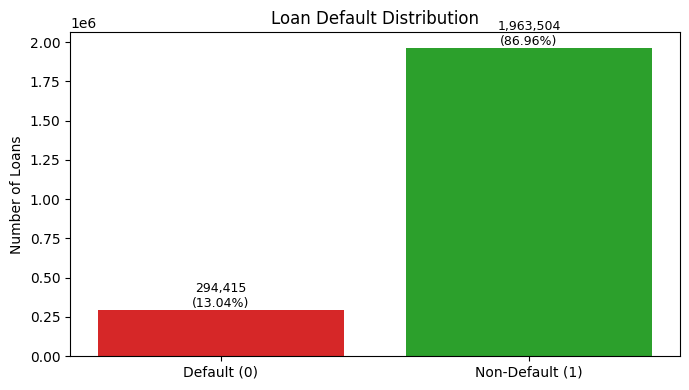

In [17]:
# Plot loan default distribution (0 = Default, 1 = Non-Default)
dist = (
    df['loan_status_binary']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

label_map = {0: 'Default (0)', 1: 'Non-Default (1)'}
labels = [label_map[i] for i in dist.index]
total = dist.sum()

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, dist.values, color=['#d62728', '#2ca02c'])

plt.title('Loan Default Distribution')
plt.ylabel('Number of Loans')

for bar, count in zip(bars, dist.values):
    pct = 100 * count / total
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count:,}\n({pct:.2f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [20]:
def missing_data_summary(df, threshold=0):
    """
    Summarizes missing data, showing count and percentage of missing values for each column.
    Filters columns based on a missing percentage threshold.
    
    Parameters:
        df (pd.DataFrame): The dataframe to analyze.
        threshold (float): The minimum percentage of missing data to include in the summary.
    
    Returns:
        pd.DataFrame: A summary of missing data.
    """
    return (pd.DataFrame(df.isna().sum())
            .reset_index()
            .rename(columns={'index': 'Column', 0: 'mis_count'})
            .query('mis_count > 0')  # Only include columns with missing values
            .assign(Missing_Percentage=lambda x: x['mis_count'] / df.shape[0] * 100)
            .query(f'Missing_Percentage > {threshold}')  # Filter by threshold
            .sort_values('mis_count', ascending=False)
            .reset_index(drop=True))

missing = missing_data_summary(df,91)
missing

,Column,mis_count,Missing_Percentage
0,member_id,2260701,100.000000
1,orig_projected_additional_accrued_interest,2252050,99.617331
2,hardship_type,2249784,99.517097
3,hardship_last_payment_amount,2249784,99.517097
4,hardship_payoff_balance_amount,2249784,99.517097
5,hardship_loan_status,2249784,99.517097
6,hardship_dpd,2249784,99.517097
7,hardship_length,2249784,99.517097
8,payment_plan_start_date,2249784,99.517097
9,hardship_end_date,2249784,99.517097


In [21]:
# Convert the first column of 'missing' to a list
columns_to_drop = missing.iloc[:, 0].tolist()

# Drop these columns from the DataFrame 'df'
df = df.drop(columns=columns_to_drop, errors='ignore')  # 'errors="ignore"' ensures no error if a column is missing

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 113 entries, id to loan_status_binary
dtypes: float64(89), object(24)
memory usage: 1.9+ GB


In [24]:
df.select_dtypes(include=['object']).head()

,id,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,pymnt_plan,...,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,next_pymnt_d,last_credit_pull_d,application_type,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,36 months,C,C4,leadman,10+ years,MORTGAGE,Not Verified,Dec-2015,n,...,PA,Aug-2003,w,Jan-2019,NaN,Mar-2019,Individual,N,Cash,N
1,68355089,36 months,C,C1,Engineer,10+ years,MORTGAGE,Not Verified,Dec-2015,n,...,SD,Dec-1999,w,Jun-2016,NaN,Mar-2019,Individual,N,Cash,N
2,68341763,60 months,B,B4,truck driver,10+ years,MORTGAGE,Not Verified,Dec-2015,n,...,IL,Aug-2000,w,Jun-2017,NaN,Mar-2019,Joint App,N,Cash,N
3,66310712,60 months,C,C5,Information Systems Officer,10+ years,MORTGAGE,Source Verified,Dec-2015,n,...,NJ,Sep-2008,w,Feb-2019,Apr-2019,Mar-2019,Individual,N,Cash,N
4,68476807,60 months,F,F1,Contract Specialist,3 years,MORTGAGE,Source Verified,Dec-2015,n,...,PA,Jun-1998,w,Jul-2016,NaN,Mar-2018,Individual,N,Cash,N


In [28]:
# Remove leading/trailing whitespaces from objects
df = df.apply(lambda col: col.str.strip() if col.dtypes == 'object' else col)

# convert dates to 'datetime' types
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['last_pymnt_d'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%Y')
df['last_credit_pull_d'] = pd.to_datetime(df['last_credit_pull_d'], format='%b-%Y')

# int_rate and revol_util for int type
df['int_rate%'] = pd.to_numeric(
    df['int_rate'].astype(str).str.strip().str.rstrip('%'),
    errors='coerce'
)
df['revol_util'] = df['revol_util'].astype(str)
df['revol_util%'] = pd.to_numeric(
    df['revol_util'].str.strip().str.rstrip('%'),
    errors='coerce'
)

columns_to_drop = {'title','zip_code','pymnt_plan', 'emp_title','int_rate','revol_util', 'url'}
df.drop(columns_to_drop, axis = 1, inplace = True)

df.debt_settlement_flag = np.where(df.debt_settlement_flag == 'Y',1,0)

df.term_36_months = np.where(df.term == '36 months',1,0)
df.drop('term', axis=1, inplace=True)

df['emp_length'] = df['emp_length'].fillna('')
df['emp_length'] = pd.to_numeric(df['emp_length'].str.replace('<', '', regex=False).str[:2].str.strip(), errors='coerce')

df.hardship_flag.fillna('N', inplace=True) #it looks like the Nans are as strings so
df.hardship_flag = np.where( df.hardship_flag == 'NaN','N', df.hardship_flag )

C:\Users\Ashvik\AppData\Local\Temp\ipykernel_19280\3130332327.py:26: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.term_36_months = np.where(df.term == '36 months',1,0)
C:\Users\Ashvik\AppData\Local\Temp\ipykernel_19280\3130332327.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.hardship_flag.fillna('N', inplace=True) #it looks like the Nans are as strings so


In [31]:
def get_sorted_unique_counts(df):
    # Select columns with categorical data
    object_cols = df.select_dtypes(include=['object', 'category']).columns
    
    # Exclude 'id' if it's in the list
    if 'id' in object_cols:
        object_cols = object_cols.drop('id')
        
    # Get the number of unique entries in each categorical column
    object_nunique = {col: df[col].nunique() for col in object_cols}
    
    # Convert to DataFrame and sort by unique counts
    unique_counts = pd.DataFrame(list(object_nunique.items()), columns=['Column', 'Unique Count'])
    unique_counts = unique_counts.sort_values(by='Unique Count').reset_index(drop=True)
    
    return unique_counts

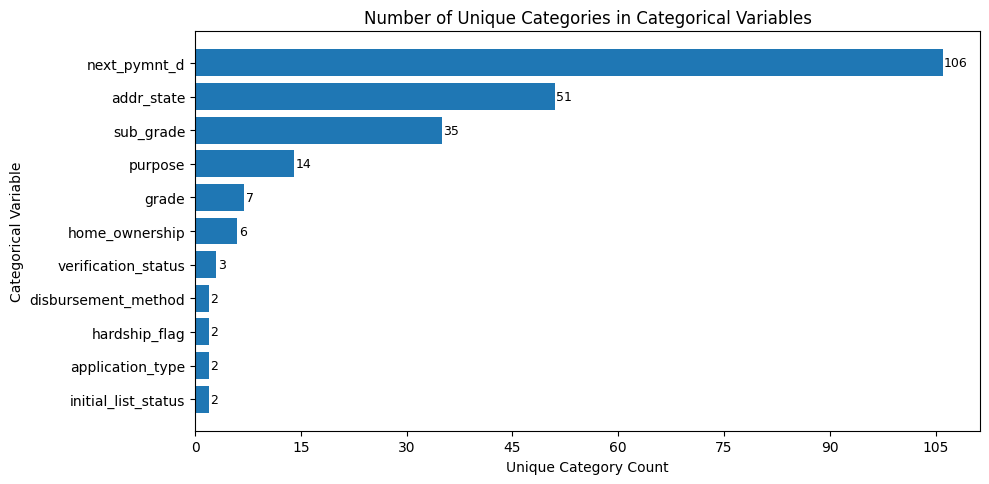

In [32]:
# Number of unique categories in categorical variables
unique_counts = get_sorted_unique_counts(df)

plt.figure(figsize=(10, max(4, 0.45 * len(unique_counts))))
bars = plt.barh(unique_counts["Column"], unique_counts["Unique Count"], color="#1f77b4")

plt.title("Number of Unique Categories in Categorical Variables")
plt.xlabel("Unique Category Count")
plt.ylabel("Categorical Variable")
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

for bar, v in zip(bars, unique_counts["Unique Count"]):
    plt.text(v + 0.2, bar.get_y() + bar.get_height()/2, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [33]:
# Audit object/category columns for cardinality, imbalance, and text inconsistencies
object_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if not object_cols:
    print('No object/category columns found.')
else:
    profile_rows = []

    for col in object_cols:
        s = df[col].astype('string')
        non_null = s.dropna()

        n_rows = len(non_null)
        n_unique = non_null.nunique(dropna=True)

        vc = non_null.value_counts(dropna=True)
        top_value = vc.index[0] if not vc.empty else pd.NA
        top_count = int(vc.iloc[0]) if not vc.empty else 0
        top_share = (top_count / n_rows * 100) if n_rows else np.nan

        # Normalize strings to surface case/space inconsistencies.
        normalized = (
            non_null
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )

        pairs = pd.DataFrame({'raw': non_null.values, 'norm': normalized.values}).dropna()
        raw_variants_per_norm = pairs.groupby('norm')['raw'].nunique()
        n_inconsistent_groups = int((raw_variants_per_norm > 1).sum())

        profile_rows.append({
            'column': col,
            'non_null_rows': n_rows,
            'unique_values': int(n_unique),
            'unique_ratio_%': round((n_unique / n_rows * 100), 2) if n_rows else np.nan,
            'top_category': str(top_value),
            'top_share_%': round(top_share, 2) if n_rows else np.nan,
            'needs_grouping_or_binning': bool(n_unique > 20),
            'severe_imbalance': bool(top_share >= 80) if n_rows else False,
            'possible_case_or_spacing_inconsistency': bool(n_inconsistent_groups > 0),
            'inconsistent_normalized_groups': n_inconsistent_groups
        })

    object_profile = pd.DataFrame(profile_rows).sort_values('unique_values', ascending=False).reset_index(drop=True)
    display(object_profile)


,column,non_null_rows,unique_values,unique_ratio_%,top_category,top_share_%,needs_grouping_or_binning,severe_imbalance,possible_case_or_spacing_inconsistency,inconsistent_normalized_groups
0,id,65245,65245,100.00,38272256,0.00,True,False,False,0
1,next_pymnt_d,915358,106,0.01,Apr-2019,99.66,True,True,False,0
2,addr_state,2260668,51,0.00,CA,13.91,True,False,False,0
3,sub_grade,2260668,35,0.00,C1,6.45,True,False,False,0
4,purpose,2260668,14,0.00,debt_consolidation,56.53,False,False,False,0
5,grade,2260668,7,0.00,B,29.35,False,False,False,0
6,home_ownership,2260668,6,0.00,MORTGAGE,49.16,False,False,False,0
7,verification_status,2260668,3,0.00,Source Verified,39.20,False,False,False,0
8,initial_list_status,2260668,2,0.00,w,67.92,False,False,False,0
9,application_type,2260668,2,0.00,Individual,94.66,False,True,False,0


In [34]:
# Focused diagnostics for requested categorical columns
focus_cols = ['purpose', 'home_ownership', 'application_type']
available_focus_cols = [c for c in focus_cols if c in df.columns]
missing_focus_cols = sorted(set(focus_cols) - set(available_focus_cols))

if missing_focus_cols:
    print('Missing columns:', missing_focus_cols)

for col in available_focus_cols:
    print(f'\n=== {col} ===')

    s = df[col].astype('string')
    non_null = s.dropna()

    normalized = (
        non_null
        .str.strip()
        .str.lower()
        .str.replace(r'\s+', ' ', regex=True)
    )

    raw_unique = non_null.nunique(dropna=True)
    norm_unique = normalized.nunique(dropna=True)

    print(f'Raw unique values: {raw_unique}')
    print(f'Normalized unique values: {norm_unique}')

    # Show variant groups that collapse after normalization (case/space issues).
    variants = (
        pd.DataFrame({'raw': non_null.values, 'norm': normalized.values})
        .groupby('norm')['raw']
        .agg(lambda x: sorted(set(x)))
    )
    variants = variants[variants.apply(len) > 1]

    if not variants.empty:
        print('Potential case/spacing inconsistencies (sample):')
        display(variants.head(10).to_frame(name='raw_variants'))
    else:
        print('No obvious case/spacing inconsistencies found.')

    # Frequency distribution + rare category flag.
    dist = non_null.value_counts(dropna=False).rename_axis(col).reset_index(name='count')
    dist['share_%'] = 100 * dist['count'] / dist['count'].sum()
    dist['rare_lt_1pct'] = dist['share_%'] < 1

    print('Category distribution:')
    display(dist)

    # If target exists, show default-rate imbalance by category.
    if 'loan_status_binary' in df.columns:
        tmp = df[[col, 'loan_status_binary']].copy()
        tmp[col] = tmp[col].astype('string')

        by_cat = (
            tmp.groupby(col, dropna=False)['loan_status_binary']
            .agg(rows='size', non_default_rate='mean')
            .reset_index()
        )
        by_cat['default_rate'] = 1 - by_cat['non_default_rate']
        by_cat = by_cat.sort_values('rows', ascending=False)

        print('Default-rate profile by category:')
        display(by_cat)



=== purpose ===
Raw unique values: 14
Normalized unique values: 14
No obvious case/spacing inconsistencies found.
Category distribution:


,purpose,count,share_%,rare_lt_1pct
0,debt_consolidation,1277877,56.526522,False
1,credit_card,516971,22.868064,False
2,home_improvement,150457,6.655422,False
3,other,139440,6.168088,False
4,major_purchase,50445,2.23142,False
5,medical,27488,1.215924,False
6,small_business,24689,1.092111,False
7,car,24013,1.062208,False
8,vacation,15525,0.686744,True
9,moving,15403,0.681347,True


Default-rate profile by category:


,purpose,rows,non_default_rate,default_rate
2,debt_consolidation,1277877,0.858995,0.141005
1,credit_card,516971,0.893886,0.106114
4,home_improvement,150457,0.885046,0.114954
9,other,139440,0.868353,0.131647
6,major_purchase,50445,0.877787,0.122213
7,medical,27488,0.863945,0.136055
11,small_business,24689,0.796559,0.203441
0,car,24013,0.901207,0.098793
12,vacation,15525,0.875855,0.124145
8,moving,15403,0.841440,0.158560



=== home_ownership ===
Raw unique values: 6
Normalized unique values: 6
No obvious case/spacing inconsistencies found.
Category distribution:


...

,home_ownership,rows,non_default_rate,default_rate
1,MORTGAGE,1111450,0.886698,0.113302
5,RENT,894929,0.848471,0.151529
4,OWN,253057,0.869091,0.130909
0,ANY,996,0.924699,0.075301
3,OTHER,182,0.812500,0.187500
2,NONE,54,0.857143,0.142857
6,<NA>,33,NaN,NaN



=== application_type ===
Raw unique values: 2
Normalized unique values: 2
No obvious case/spacing inconsistencies found.
Category distribution:


,application_type,count,share_%,rare_lt_1pct
0,Individual,2139958,94.660428,False
1,Joint App,120710,5.339572,False


Default-rate profile by category:


,application_type,rows,non_default_rate,default_rate
0,Individual,2139958,0.866470,0.133530
1,Joint App,120710,0.925159,0.074841
2,<NA>,33,NaN,NaN


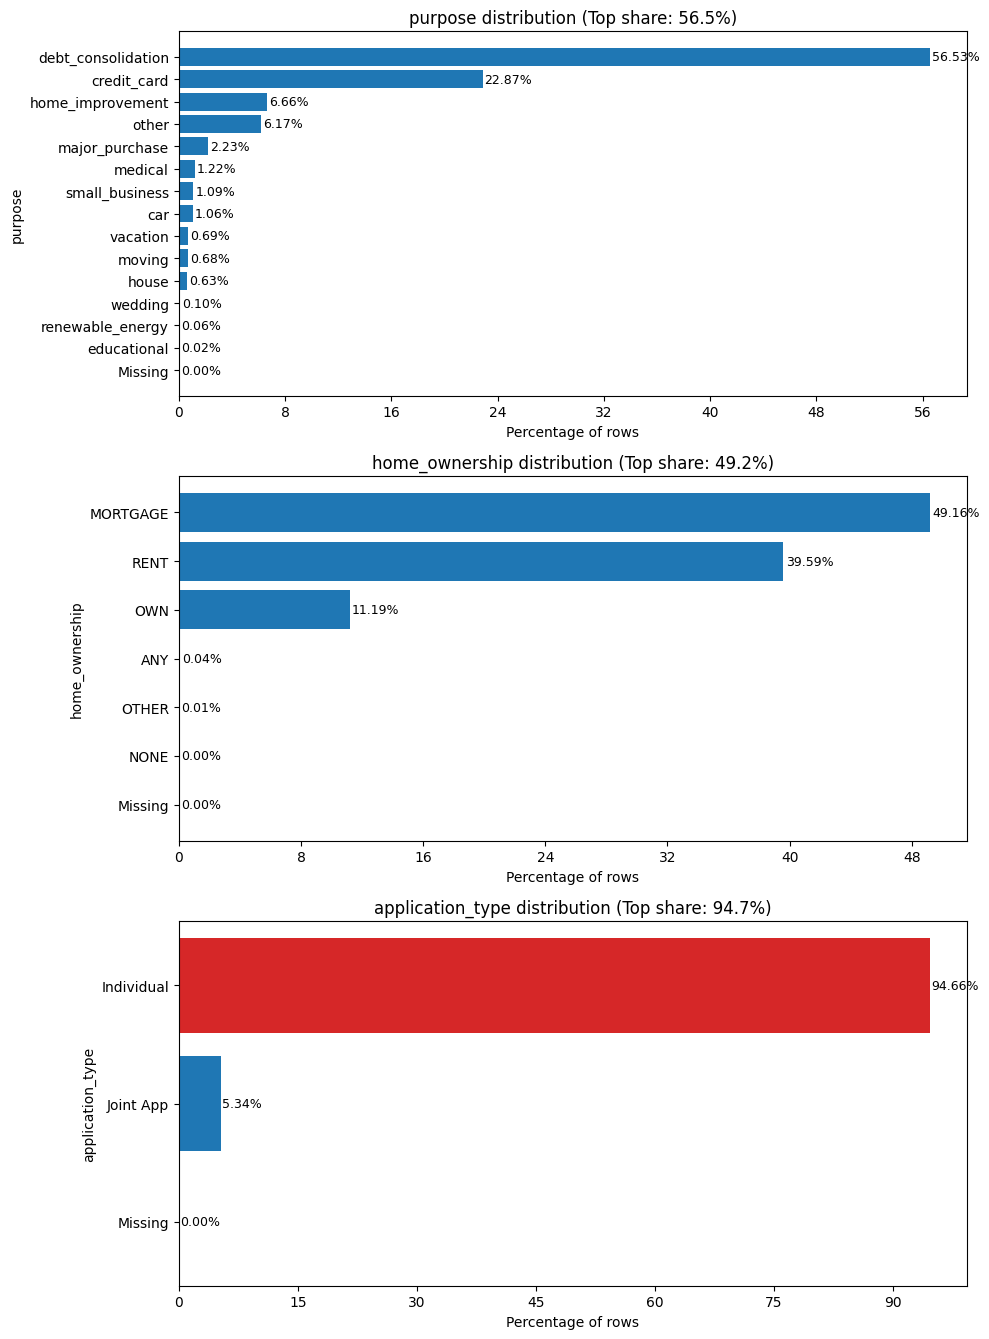

In [35]:
# Plot distributions for purpose, home_ownership, and application_type
plot_cols = [c for c in ['purpose', 'home_ownership', 'application_type'] if c in df.columns]

if not plot_cols:
    print('None of the requested columns are available for plotting.')
else:
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 4.5 * len(plot_cols)))

    if len(plot_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, plot_cols):
        counts = df[col].astype('string').fillna('Missing').value_counts()
        shares = (counts / counts.sum() * 100).sort_values(ascending=True)

        max_share = shares.max() if len(shares) else 0
        colors = ['#d62728' if v == max_share and max_share >= 60 else '#1f77b4' for v in shares.values]

        bars = ax.barh(shares.index.astype(str), shares.values, color=colors)

        ax.set_title(f'{col} distribution (Top share: {max_share:.1f}%)')
        ax.set_xlabel('Percentage of rows')
        ax.set_ylabel(col)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))

        for bar, pct in zip(bars, shares.values):
            ax.text(pct + 0.15, bar.get_y() + bar.get_height() / 2, f'{pct:.2f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
